✅ Données prêtes pour le clustering : 82332 échantillons.
⏳ Calcul des scores pour K allant de 2 à 10...


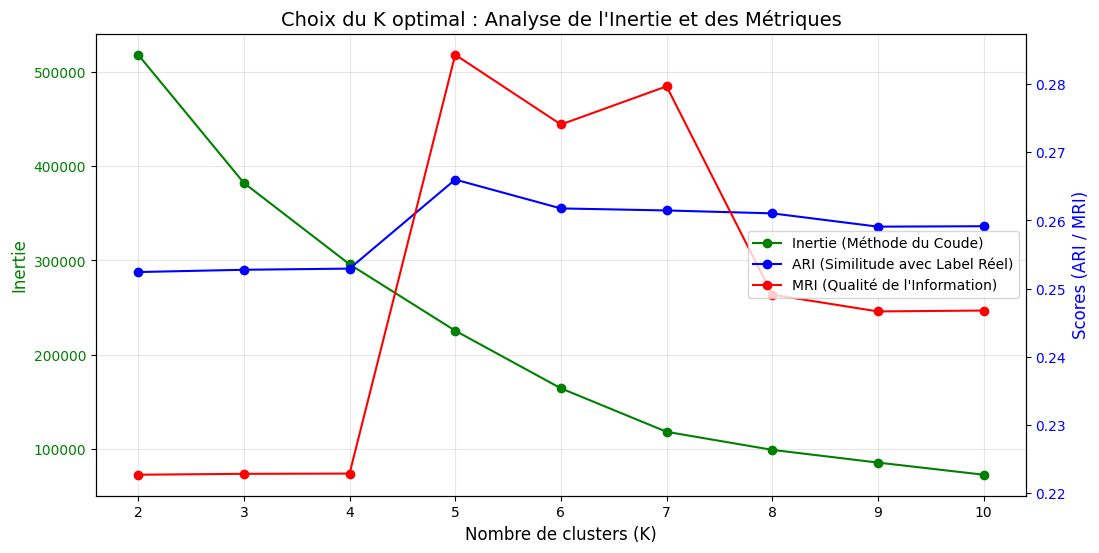

-----------------------------------
🎯 RÉSULTATS DU MODÈLE FINAL (K=5)
-----------------------------------
ARI : 0.2660
MRI : 0.2843
-----------------------------------


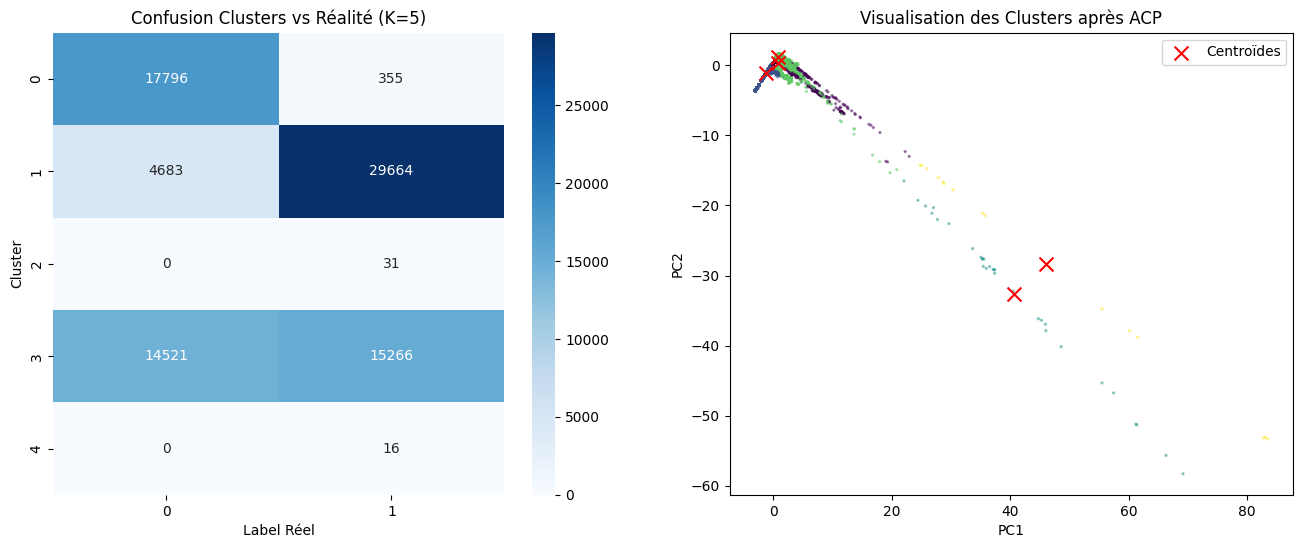

In [9]:
# %% [markdown]
# # Étape 2 : Analyse de Performance et Choix du K Optimal

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# --- 1. Préparation et Chargement ---
OUTPUT_PATH = Path("../output")
DATA_PATH = Path("../data")

# Rechargement sécurisé des données réduites et des labels
X = np.load(OUTPUT_PATH / "X_reduced_5.npy")
df_train = pd.read_csv(DATA_PATH / "UNSW_NB15_training-set.csv")
y_true = df_train['label']

print(f"✅ Données prêtes pour le clustering : {X.shape[0]} échantillons.")

# %% [markdown]
# ### 1. Étude du nombre de clusters (K)
# Nous utilisons la méthode du coude (Inertie) couplée aux métriques ARI et MRI 
# pour identifier le point de rupture optimal.
# %%
list_k = range(2, 11)
ari_scores = []
mri_scores = []
inertias = []

print("⏳ Calcul des scores pour K allant de 2 à 10...")
for k in list_k:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X)
    
    # Métriques
    inertias.append(km.inertia_)
    ari_scores.append(adjusted_rand_score(y_true, labels))
    mri_scores.append(normalized_mutual_info_score(y_true, labels))

# --- Graphique de Diagnostic ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Axe 1 : Inertie (Le Coude)
ax1.plot(list_k, inertias, 'go-', label="Inertie (Méthode du Coude)")
ax1.set_xlabel('Nombre de clusters (K)', fontsize=12)
ax1.set_ylabel('Inertie', color='g', fontsize=12)
ax1.tick_params(axis='y', labelcolor='g')
ax1.grid(True, alpha=0.3)

# Axe 2 : Scores de performance
ax2 = ax1.twinx()
ax2.plot(list_k, ari_scores, 'bo-', label="ARI (Similitude avec Label Réel)")
ax2.plot(list_k, mri_scores, 'ro-', label="MRI (Qualité de l'Information)")
ax2.set_ylabel('Scores (ARI / MRI)', color='b', fontsize=12)
ax2.tick_params(axis='y', labelcolor='b')

plt.title("Choix du K optimal : Analyse de l'Inertie et des Métriques", fontsize=14)
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='center right')
plt.show()

# %% [markdown]
# ### 2. Exécution du K-Means avec K=5
# D'après l'analyse ci-dessus, K=5 présente un pic de performance MRI/ARI 
# et un coude marqué dans l'inertie.
# %%
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, random_state=42)
y_pred = kmeans.fit_predict(X)

print("-" * 35)
print(f"🎯 RÉSULTATS DU MODÈLE FINAL (K={n_clusters})")
print("-" * 35)
print(f"ARI : {adjusted_rand_score(y_true, y_pred):.4f}")
print(f"MRI : {normalized_mutual_info_score(y_true, y_pred):.4f}")
print("-" * 35)

# %% [markdown]
# ### 3. Matrice de Confusion et Projection Spatiale
# %%
ct = pd.crosstab(y_pred, y_true, rownames=['Cluster'], colnames=['Label Réel'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title(f"Confusion Clusters vs Réalité (K={n_clusters})")

# Scatter Plot
ax2.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=2, alpha=0.4)
ax2.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            c='red', marker='x', s=100, label='Centroïdes')
ax2.set_title("Visualisation des Clusters après ACP")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.legend()

plt.show()